# 04 — Redes Convolucionales 1D (Conv1D)
Input `(N, V_in, 23)`. Conv1D extrae patrones locales en la dimensión temporal.
Catálogo activo: **conv_s** (Conv1D + GlobalAvgPool). Descomentar `[EXTENDER]` para más variantes.

> Nota: Conv1D requiere V_in ≥ kernel_size (3). Para V_in=5 funciona correctamente.

https://github.com/Romequinco/TAREA_REDES_NEURONALES

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, yfinance as yf
warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_mae_matrix, build_results_df, best_per_window)

In [4]:
# ── HIPERPARÁMETROS ───────────────────────────────────────────
EPOCHS     = 150
BATCH_SIZE = 64
QUICK_MODE = False
if QUICK_MODE: EPOCHS = 50

precios = yf.download(TICKERS, start='1945-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}')

Retornos: (16191, 23)  |  EPOCHS=150


## Individualizando

Existen **16 posibles combinaciones** de tamaños de ventanas de entrada-salida. Estas combinaciones se obtienen al cruzar las ventanas de entrada (`V_in`) con las ventanas de salida (`V_out`).

Las combinaciones consideradas son:

| Nº | `V_in` días | `V_out` días |
|---:|------------:|-------------:|
| 1  | 5  | 1  |
| 2  | 5  | 5  |
| 3  | 5  | 30 |
| 4  | 5  | 90 |
| 5  | 10 | 1  |
| 6  | 10 | 5  |
| 7  | 10 | 30 |
| 8  | 10 | 90 |
| 9  | 30 | 1  |
| 10 | 30 | 5  |
| 11 | 30 | 30 |
| 12 | 30 | 90 |
| 13 | 90 | 1  |
| 14 | 90 | 5  |
| 15 | 90 | 30 |
| 16 | 90 | 90 |

Se entrenará **un modelo para cada combinación de ventanas**, con el objetivo de comparar su rendimiento y determinar cuál de ellas ofrece la mejor opción.

### Modelo 1

In [5]:
# Elegir UNA configuración concreta
V_in  = 5   # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.0001

model_1 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.01

model_1.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist = model_1.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

restore_best_weights(model_1)

# Evaluación
result = {
    'train': eval_mae(model_1, X_tr, y_tr),
    'val':   eval_mae(model_1, X_v, y_v),
    'test':  eval_mae(model_1, X_ts, y_ts),
    'params': model_1.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist.history["loss"])}'
)

Epoch 1/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - mae: 0.0121 - val_loss: 0.0113 - val_mae: 0.0113 - learning_rate: 0.0100
Epoch 2/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0121 - mae: 0.0121 - val_loss: 0.0109 - val_mae: 0.0109 - learning_rate: 0.0100
Epoch 3/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0120 - mae: 0.0120 - val_loss: 0.0110 - val_mae: 0.0110 - learning_rate: 0.0100
Epoch 4/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0120 - mae: 0.0120 - val_loss: 0.0112 - val_mae: 0.0112 - learning_rate: 0.0100
Epoch 5/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0121 - mae: 0.0121 - val_loss: 0.0114 - val_mae: 0.0114 - learning_rate: 0.0100
Epoch 6/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0121 - mae: 0.0121 - val_loss: 0.0110 - val_mae: 0.0110 - learning_rate: 0.0100
Epoch 7/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0121 - mae: 0.0121 - val_loss: 0.0109 - val_mae: 0.0109 - learning_rate: 0.0100

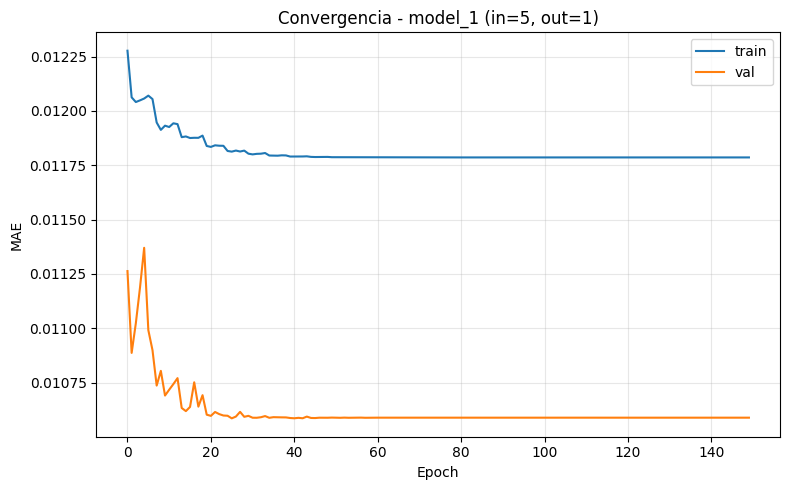

In [6]:
plt.figure(figsize=(12, 7), dpi=140)
plt.plot(hist.history['loss'], label='train')
plt.plot(hist.history['val_loss'], label='val')

plt.title(f'Convergencia - model_1 (in={V_in}, out={V_out})', fontsize=16)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MAE', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Catálogo de arquitecturas Conv1D

In [3]:
# Input shape: (V_in, 23) — la convolución opera sobre la dimensión temporal
MODELOS = {
    'conv_s': lambda V: compile_model(Sequential([
        Input((V, 23)),
        Conv1D(64, kernel_size=3, activation='relu'),
        GlobalAveragePooling1D(),
        Dense(23)])),

    # 'conv_gmp': lambda V: compile_model(Sequential([       # [EXTENDER] GlobalMaxPool
    #     Input((V, 23)),
    #     Conv1D(128, kernel_size=3, activation='relu'),
    #     GlobalMaxPooling1D(),
    #     Dense(23)])),

    # 'conv_d': lambda V: compile_model(Sequential([         # [EXTENDER] doble conv
    #     Input((V, 23)),
    #     Conv1D(64, kernel_size=3, activation='relu'),
    #     Conv1D(128, kernel_size=3, activation='relu'),
    #     GlobalAveragePooling1D(),
    #     Dense(23)])),
}

## Entrenamiento

In [5]:
results     = {}
historiales = {}

for nombre, build_fn in MODELOS.items():
    for V_in in INPUT_WINDOWS:
        for V_out in OUTPUT_WINDOWS:
            X, y = create_time_series_data(returns, V_in, V_out)
            X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

            model = build_fn(V_in)
            hist  = model.fit(X_tr, y_tr,
                              validation_data=(X_v, y_v),
                              epochs=EPOCHS, batch_size=BATCH_SIZE,
                              callbacks=get_callbacks(), verbose=0)
            restore_best_weights(model)

            key = (nombre, V_in, V_out)
            results[key]     = {'train':  eval_mae(model, X_tr, y_tr),
                                'val':    eval_mae(model, X_v,  y_v),
                                'test':   eval_mae(model, X_ts, y_ts),
                                'params': model.count_params()}
            historiales[key] = hist
            print(f'{nombre}  in={V_in:2d}  out={V_out:2d}  '
                  f'train={results[key]["train"]:.4f}  '
                  f'val={results[key]["val"]:.4f}  '
                  f'test={results[key]["test"]:.4f}  '
                  f'ep={len(hist.history["loss"])}')

conv_s  in= 5  out= 1  train=0.0118  val=0.0106  test=0.0122  ep=300
conv_s  in= 5  out= 5  train=0.0055  val=0.0048  test=0.0056  ep=300
conv_s  in= 5  out=30  train=0.0022  val=0.0020  test=0.0024  ep=300
conv_s  in= 5  out=90  train=0.0012  val=0.0011  test=0.0013  ep=300
conv_s  in=10  out= 1  train=0.0118  val=0.0106  test=0.0122  ep=300
conv_s  in=10  out= 5  train=0.0054  val=0.0048  test=0.0056  ep=300
conv_s  in=10  out=30  train=0.0022  val=0.0020  test=0.0024  ep=300
conv_s  in=10  out=90  train=0.0012  val=0.0012  test=0.0014  ep=300
conv_s  in=30  out= 1  train=0.0118  val=0.0106  test=0.0123  ep=300
conv_s  in=30  out= 5  train=0.0054  val=0.0048  test=0.0056  ep=300
conv_s  in=30  out=30  train=0.0021  val=0.0020  test=0.0024  ep=300
conv_s  in=30  out=90  train=0.0012  val=0.0012  test=0.0014  ep=300
conv_s  in=90  out= 1  train=0.0118  val=0.0106  test=0.0123  ep=300
conv_s  in=90  out= 5  train=0.0055  val=0.0048  test=0.0056  ep=300
conv_s  in=90  out=30  train=0.002

## Curvas de convergencia

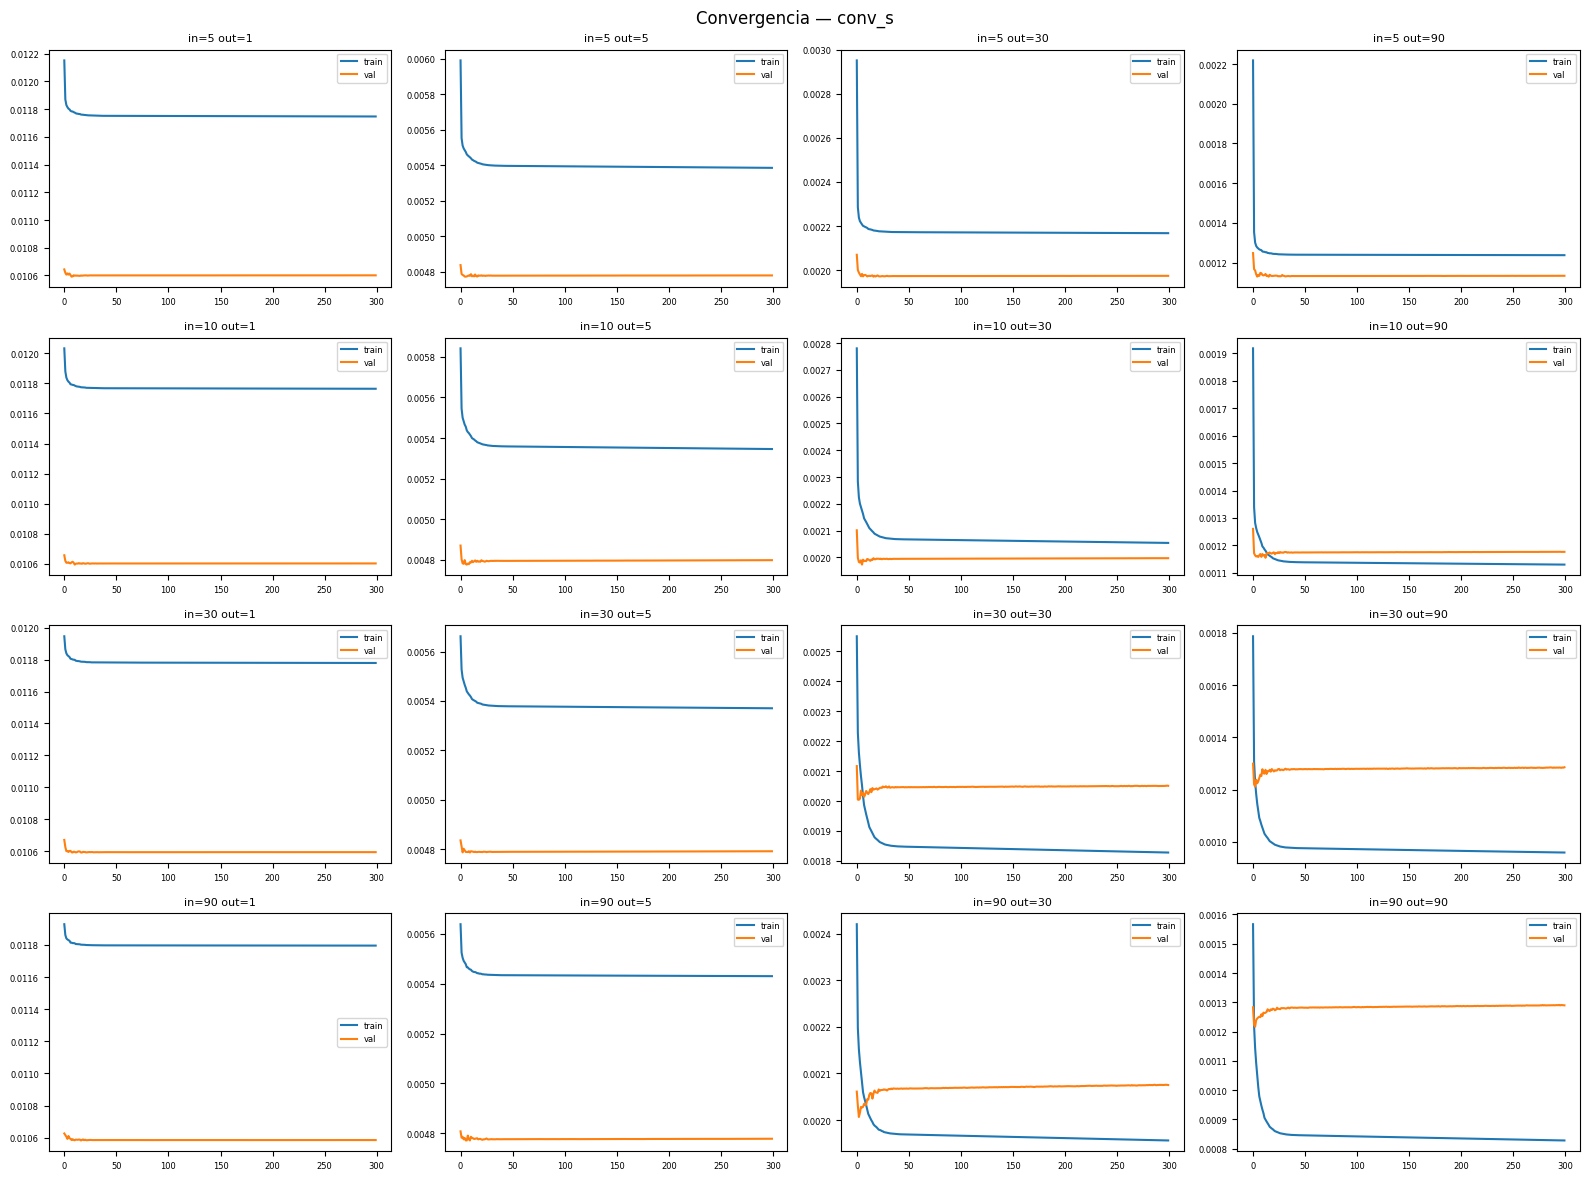

In [ ]:
for nombre in MODELOS:
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    for i, V_in in enumerate(INPUT_WINDOWS):
        for j, V_out in enumerate(OUTPUT_WINDOWS):
            hist = historiales[(nombre, V_in, V_out)]
            ax = axes[i][j]
            ax.plot(hist.history['loss'],     label='train')
            ax.plot(hist.history['val_loss'], label='val')
            ax.set_title(f'in={V_in} out={V_out}', fontsize=8)
            ax.legend(fontsize=6); ax.tick_params(labelsize=6)
    plt.suptitle(f'Convergencia — {nombre}', fontsize=12)
    plt.tight_layout(); plt.show()

## Resultados

                      train       val      test  params
modelo V_in V_out                                      
conv_s 5    1      0.011785  0.010591  0.012244    5975
            5      0.005469  0.004771  0.005621    5975
            30     0.002180  0.001970  0.002366    5975
            90     0.001247  0.001129  0.001325    5975
       10   1      0.011788  0.010594  0.012244    5975
            5      0.005431  0.004777  0.005628    5975
            30     0.002162  0.001973  0.002384    5975
            90     0.001176  0.001155  0.001355    5975
       30   1      0.011799  0.010591  0.012250    5975
            5      0.005416  0.004786  0.005625    5975
            30     0.002136  0.002004  0.002431    5975
            90     0.001204  0.001212  0.001388    5975
       90   1      0.011801  0.010583  0.012272    5975
            5      0.005456  0.004771  0.005616    5975
            30     0.002134  0.002007  0.002391    5975
            90     0.001117  0.001217  0.001425 

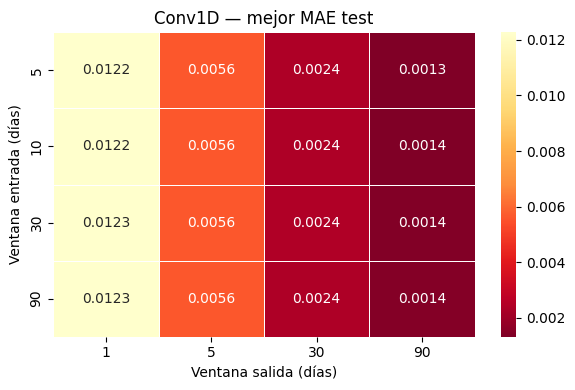

In [7]:
df_res = build_results_df(results)
print(df_res.to_string())

mat = best_per_window(df_res, metric='test')
plot_mae_matrix(mat, title='Conv1D — mejor MAE test')